# 08 — Regression Backtest 2025 (OOS)

**Out-of-sample:** monthly 1M forward-return predictions from the refitted regression model (saved in notebook 07 as `data/models/regression_model_train.joblib`) vs **equal-weight benchmark**, **long/short**, and a **classification** forward test on the same universe (`final_classifier.joblib`, single cutoff `OOS_FEATURE_CUTOFF_DATE`).

- **Regression:** monthly rebalancing — Top-*N* predicted return → long-only; optional long/short vs bottom-*N*.
- **Classification:** one prediction per year (Q4 2024 features) — Top-*N* Winners by `P(Winner)` vs full-year 2025 returns (`evaluate_forward`).

Run notebook 07 first to produce the regression artefact. Classification models come from notebook 05 (`data/models/final_classifier.joblib`).

In [1]:
from __future__ import annotations

import logging
import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.backtest import (
    build_oos_features,
    compute_oos_returns,
    evaluate_forward,
    plot_cumulative_returns,
    strategy_summary,
)
from src.data_loader import download_ohlcv, load_fundamentals
from src.model import load_model, predict, predict_proba
from src.regression_backtest import (
    backtest_summary_table,
    plot_backtest_cumulative,
    plot_monthly_ic,
    plot_monthly_turnover,
    plot_quantile_returns,
    predict_all_months,
    run_regression_backtest,
)
from src.regression_model import load_regression_model
from src.regression_targets import compute_monthly_forward_returns
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

OOS_YEAR = config.OOS_YEAR
OOS_START_MONTH = f"{OOS_YEAR}-01"
OOS_END_MONTH = f"{OOS_YEAR}-12"

# Align long leg size: regression Top-N vs classification Top-N Winners by probability
TOP_N = 10
COSTS_BPS = 0.0  # set e.g. 20 for 20 bps one-way at rebalance (regression) / entry+exit (classification)

REG_MODEL_PATH = config.DATA_DIR / "models" / "regression_model_train.joblib"
CLS_MODEL_PATH = config.DATA_DIR / "models" / "final_classifier.joblib"

TICKER_LIMIT: int | None = None

print(f"Project root: {PROJECT_ROOT}")
print(f"OOS window: {OOS_START_MONTH} … {OOS_END_MONTH}  |  Top-N={TOP_N}  |  costs={COSTS_BPS} bps")
print(f"Regression model: {REG_MODEL_PATH}")
print(f"Classifier: {CLS_MODEL_PATH}")


/Users/stephangath/miniforge3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Project root: /Users/stephangath/cursorAi/Stock Analysis AI
OOS window: 2025-01 … 2025-12  |  Top-N=10  |  costs=0.0 bps
Regression model: /Users/stephangath/cursorAi/Stock Analysis AI/data/models/regression_model_train.joblib
Classifier: /Users/stephangath/cursorAi/Stock Analysis AI/data/models/final_classifier.joblib


## 1 — Universe, OHLCV, fundamentals

Same liquidity filter and caches as notebooks 06–07.

In [2]:
tickers_all = get_spi_extra_tickers()
ohlcv_by_ticker = download_ohlcv(
    tickers_all,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=config.DATA_DIR,
    max_workers=8,
)
passed = filter_by_min_volume(ohlcv_by_ticker, config.MIN_DAILY_VOLUME_CHF)
tickers = passed
if TICKER_LIMIT is not None:
    tickers = tickers[:TICKER_LIMIT]
ohlcv_by_ticker = {t: ohlcv_by_ticker[t] for t in tickers if t in ohlcv_by_ticker}
print(f"Universe: {len(tickers)} tickers")

fundamentals_by_ticker: dict[str, dict] = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {pool.submit(load_fundamentals, t, cache_dir=config.DATA_DIR): t for t in tickers}
    for fut in as_completed(futs):
        t = futs[fut]
        try:
            fundamentals_by_ticker[t] = fut.result()
        except Exception as exc:
            fundamentals_by_ticker[t] = {}
            logging.warning("Fundamentals failed for %s: %s", t, exc)


ERROR yfinance: 
1 Failed download:


ERROR yfinance: ['ACHI.SW']: YFTzMissingError('possibly delisted; no timezone found')


ERROR yfinance: HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}


ERROR yfinance: 
1 Failed download:


ERROR yfinance: ['AFP.SW']: YFTzMissingError('possibly delisted; no timezone found')


...

WARNING src.data_loader: OHLCV download failed for VIFN.SW: RuntimeError: empty response


WARNING src.data_loader: OHLCV download failed for WKB.SW: RuntimeError: empty response


WARNING src.data_loader: OHLCV download failed for ZG.SW: RuntimeError: empty response


WARNING src.data_loader: OHLCV download failed for ZWN.SW: RuntimeError: empty response


Universe: 136 tickers


## 2 — Regression: monthly OOS panel, predictions, portfolio backtest

`compute_monthly_forward_returns` builds realized 1M returns for each month-end cutoff in 2025. `predict_all_months` applies the trained regressor at each cutoff (no lookahead). `run_regression_backtest` stitches daily returns across monthly rebalances.

In [3]:
if not REG_MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {REG_MODEL_PATH}. Run notebook 07 (refit + save) first."
    )

train_result_reg = load_regression_model(REG_MODEL_PATH)

fwd_oos = compute_monthly_forward_returns(
    ohlcv_by_ticker,
    start_month=OOS_START_MONTH,
    end_month=OOS_END_MONTH,
)
print(f"OOS forward-return rows: {len(fwd_oos)}")
if fwd_oos.empty:
    raise ValueError("No forward returns for OOS — check YF_END and OHLCV coverage.")

pred_by_month = predict_all_months(
    train_result_reg,
    ohlcv_by_ticker,
    fwd_oos,
    fundamentals_by_ticker=fundamentals_by_ticker,
)
print(f"Months with predictions: {len(pred_by_month)}")

result_reg = run_regression_backtest(
    ohlcv_by_ticker,
    pred_by_month,
    fwd_oos,
    top_n=TOP_N,
    bottom_n=TOP_N,
    costs_bps=COSTS_BPS,
    n_quantiles=5,
)

display(backtest_summary_table(result_reg))
if not result_reg.summary_df.empty:
    display(result_reg.summary_df)


/Users/stephangath/miniforge3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/stephangath/miniforge3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


INFO src.regression_targets: compute_monthly_forward_returns: 1493 rows (11 months × ~135 tickers/row)


OOS forward-return rows: 1493


INFO src.features: Feature matrix: 136 tickers x 38 features (NaN rate 5.8%)


INFO src.features: Feature matrix: 136 tickers x 38 features (NaN rate 5.8%)


...

INFO src.regression_backtest:   long_short   cum=0.067  ann=0.081  sharpe=0.72  maxDD=-0.071  (209 days)


INFO src.regression_backtest:   benchmark    cum=0.016  ann=0.020  sharpe=0.16  maxDD=-0.141  (209 days)


INFO src.regression_backtest:   IC: mean=0.0367  std=0.0902  IR=0.41  positive=73%


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days,avg_monthly_turnover
Strategy,,,,,,,
Long-Only (Top-10),-0.0558,-0.0668,0.2517,-0.2656,-0.2699,209,0.5818
Short-Only (Bottom-10),0.1637,0.2005,0.2164,0.9266,-0.1802,209,0.6455
Long/Short,0.0668,0.0811,0.1120,0.7245,-0.0712,209,0.6136
Benchmark (EW),0.0163,0.0197,0.1245,0.1585,-0.1405,209,–


,cutoff_date,ic,n_universe,n_long,n_short,turnover_long,turnover_short,long_return,short_return,ls_return,benchmark_return
0,2025-01-31,0.011516,136,10,10,1.0,1.0,-0.057573,0.062188,-0.059881,0.009003
1,2025-02-28,0.048112,136,10,10,0.5,0.7,-0.115912,-0.176589,0.030338,-0.037148
2,2025-03-31,0.085250,136,10,10,0.6,0.7,0.002985,-0.042773,0.022879,-0.006747
3,2025-04-30,0.258515,136,10,10,0.6,0.6,0.119650,0.068563,0.025544,0.047268
4,2025-05-30,0.047870,136,10,10,0.5,0.5,0.041619,0.005338,0.018140,0.005973
5,2025-06-30,0.107614,136,10,10,0.8,0.6,0.057088,0.008739,0.024174,0.023641
6,2025-07-31,-0.049521,136,10,10,0.6,0.5,-0.026089,-0.065574,0.019743,-0.013024
7,2025-08-29,-0.103025,136,10,10,0.4,0.8,-0.030308,-0.015060,-0.007624,-0.021556
8,2025-09-30,0.003745,136,10,10,0.3,0.5,0.015201,0.010038,0.002581,0.020811
9,2025-10-31,0.016750,136,10,10,0.8,0.7,-0.017351,-0.011986,-0.002682,-0.005736


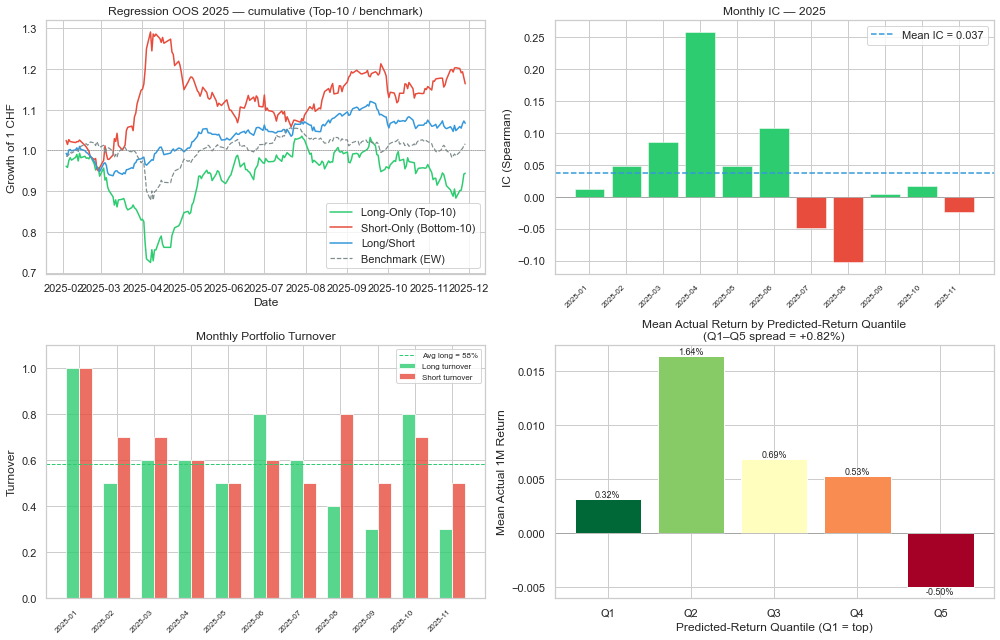

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_backtest_cumulative(
    result_reg,
    title=f"Regression OOS {OOS_YEAR} — cumulative (Top-{TOP_N} / benchmark)",
    ax=axes[0, 0],
)
plot_monthly_ic(result_reg, title=f"Monthly IC — {OOS_YEAR}", ax=axes[0, 1])
plot_monthly_turnover(result_reg, ax=axes[1, 0])
plot_quantile_returns(result_reg, ax=axes[1, 1])
plt.tight_layout()
plt.show()


## 3 — Classification: single cutoff, full-year 2025

Features through `OOS_FEATURE_CUTOFF_DATE` (Q4 2024), **one** prediction for all of 2025, equal-weight long-Winners (optionally Top-*N* by `P(Winner)`). Same `COSTS_BPS` as above for the classification leg.

In [5]:
if not CLS_MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {CLS_MODEL_PATH}. Train/save the classifier in notebook 05."
    )

train_result_cls = load_model(CLS_MODEL_PATH)
X_oos = build_oos_features(
    ohlcv_by_ticker,
    fundamentals_by_ticker=fundamentals_by_ticker,
    cutoff_date=config.OOS_FEATURE_CUTOFF_DATE,
)
pred_cls = predict(train_result_cls, X_oos)
proba_df = predict_proba(train_result_cls, X_oos)
pw = proba_df["Winners"] if "Winners" in proba_df.columns else None

oos_returns = compute_oos_returns(ohlcv_by_ticker, year=OOS_YEAR)

ftr_cls = evaluate_forward(
    pred_cls,
    oos_returns,
    ohlcv_by_ticker,
    year=OOS_YEAR,
    costs_bps=COSTS_BPS,
    proba_weights=pw,
    top_n=TOP_N,
)

display(strategy_summary(ftr_cls))
print("Accuracy:", ftr_cls.classification.get("accuracy"))


/Users/stephangath/miniforge3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


/Users/stephangath/miniforge3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/stephangath/miniforge3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
INFO src.backtest: Building OOS features with cutoff=2024-12-31


INFO src.features: Feature matrix: 136 tickers x 38 features (NaN rate 5.8%)


INFO src.backtest: OOS returns (2025): n=136  mean=0.113  median=0.068  (NaN: 0)


INFO src.backtest: Evaluating forward test: 136 tickers with predictions and returns


...

INFO src.backtest: Strategy 'short_losers': cum=-0.070  sharpe=-0.44  maxDD=-0.205  (248 days)


INFO src.backtest: Strategy 'long_short': cum=0.226  sharpe=2.21  maxDD=-0.060  (248 days)


INFO src.backtest: Strategy 'benchmark': cum=0.097  sharpe=0.83  maxDD=-0.141  (248 days)


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,0.5588,0.5700,0.2605,2.1877,-0.2319,248
Long/Short,0.2258,0.2298,0.1039,2.2108,-0.0599,248
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


Accuracy: 0.4852941176470588


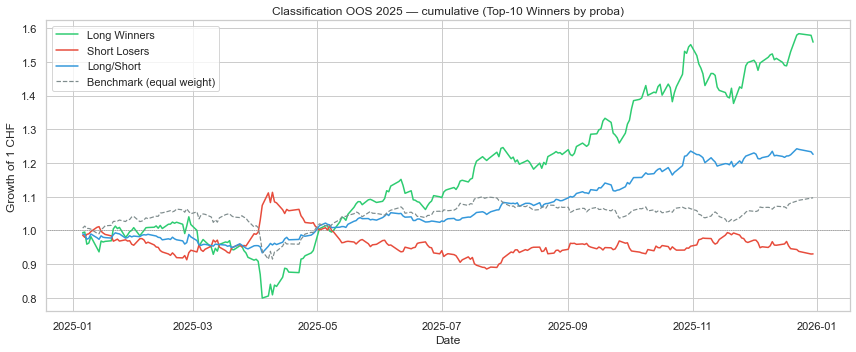

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_cumulative_returns(
    ftr_cls.daily_returns,
    title=f"Classification OOS {OOS_YEAR} — cumulative (Top-{TOP_N} Winners by proba)",
    ax=ax,
)
plt.tight_layout()
plt.show()


## 4 — Side-by-side: regression vs classification

Compare **long-only** legs: regression rebalances monthly using predicted 1M returns; classification holds a fixed Winner basket for the calendar year. Benchmarks differ (monthly EW universe vs one-year EW all names) — interpret accordingly.

,Cumulative,Ann. return,Sharpe,Max DD,Vol (ann.),Days
Strategy,,,,,,
"Regression long-only (Top-10, monthly)",-0.0558,-0.0668,-0.2656,-0.2699,0.2517,209
"Regression benchmark (EW, monthly)",0.0163,0.0197,0.1585,-0.1405,0.1245,209
"Classification long-Winners (Top-10 by P(W), yearly hold)",0.5588,0.5700,2.1877,-0.2319,0.2605,248
"Classification benchmark (EW, yearly)",0.0968,0.0985,0.8270,-0.1405,0.1191,248


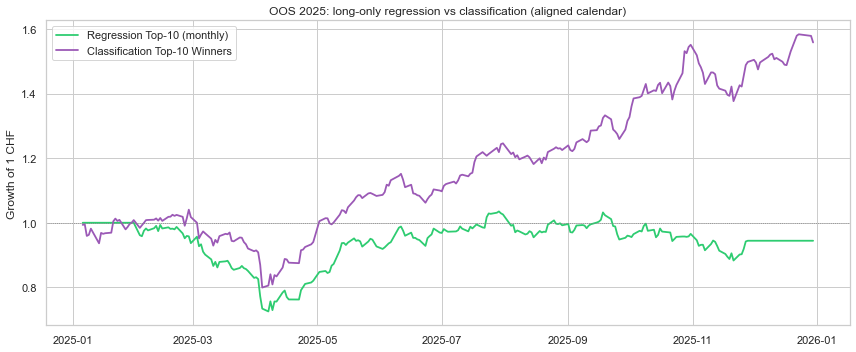

In [7]:
def _metrics_row(name: str, m: dict) -> dict:
    return {
        "Strategy": name,
        "Cumulative": m.get("cumulative_return", float("nan")),
        "Ann. return": m.get("annualized_return", float("nan")),
        "Sharpe": m.get("sharpe_ratio", float("nan")),
        "Max DD": m.get("max_drawdown", float("nan")),
        "Vol (ann.)": m.get("volatility", float("nan")),
        "Days": m.get("n_trading_days", 0),
    }


rows = [
    _metrics_row(
        f"Regression long-only (Top-{TOP_N}, monthly)",
        result_reg.strategy_metrics.get("long_only", {}),
    ),
    _metrics_row(
        f"Regression benchmark (EW, monthly)",
        result_reg.strategy_metrics.get("benchmark", {}),
    ),
    _metrics_row(
        f"Classification long-Winners (Top-{TOP_N} by P(W), yearly hold)",
        ftr_cls.long_only,
    ),
    _metrics_row(
        "Classification benchmark (EW, yearly)",
        ftr_cls.benchmark,
    ),
]
cmp = pd.DataFrame(rows).set_index("Strategy")
display(cmp.round(4))

# --- Combined equity curves (long-only legs, common calendar) ---
dr_reg = result_reg.daily_returns.get("long_only", pd.Series(dtype=float))
dr_cls = ftr_cls.daily_returns.get("long_winners", pd.Series(dtype=float))
idx = dr_reg.index.union(dr_cls.index).sort_values()
w_reg = (1 + dr_reg.reindex(idx).fillna(0.0)).cumprod()
w_cls = (1 + dr_cls.reindex(idx).fillna(0.0)).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(w_reg.index, w_reg.values, label=f"Regression Top-{TOP_N} (monthly)", color="#2ecc71", lw=1.8)
ax.plot(w_cls.index, w_cls.values, label=f"Classification Top-{TOP_N} Winners", color="#9b59b6", lw=1.8)
ax.axhline(1.0, color="gray", ls=":", lw=0.8)
ax.set_title(f"OOS {OOS_YEAR}: long-only regression vs classification (aligned calendar)")
ax.set_ylabel("Growth of 1 CHF")
ax.legend()
plt.tight_layout()
plt.show()
